<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/vrp/Roteiriza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

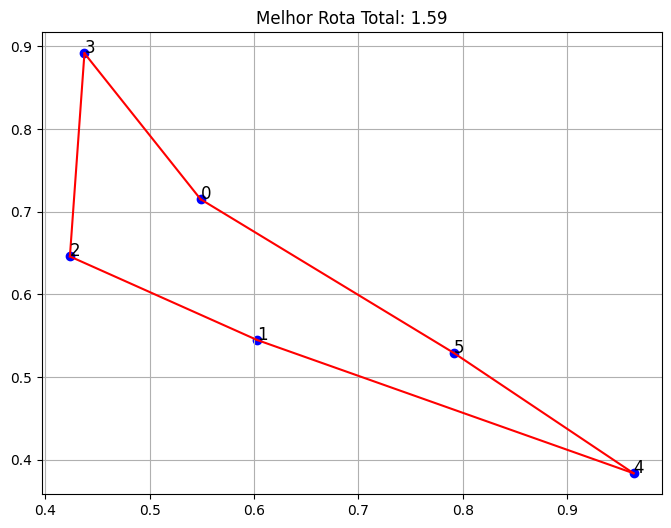

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import itertools
import numpy as np

# Gerar pontos de entrega aleatórios
np.random.seed(0)
num_pontos = 6
pontos = np.random.rand(num_pontos, 2)

# Criar grafo completo com pesos de distância euclidiana
G = nx.complete_graph(num_pontos)
for i, j in G.edges():
    dist = np.linalg.norm(pontos[i] - pontos[j])
    G.edges[i, j]['weight'] = dist

# Encontrar melhor rota (força bruta para poucos pontos)
melhor_rota = None
menor_dist = float('inf')
for perm in itertools.permutations(range(num_pontos)):
    dist = sum(G.edges[perm[i], perm[i+1]]['weight'] for i in range(len(perm)-1))
    dist += G.edges[perm[-1], perm[0]]['weight']  # volta ao início
    if dist < menor_dist:
        menor_dist = dist
        melhor_rota = perm

# Visualizar a melhor rota
plt.figure(figsize=(8, 6))
for i, ponto in enumerate(pontos):
    plt.scatter(*ponto, color='blue')
    plt.text(ponto[0], ponto[1], f'{i}', fontsize=12)
rota = list(melhor_rota) + [melhor_rota[0]]
for i in range(len(rota)-1):
    p1, p2 = pontos[rota[i]], pontos[rota[i+1]]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-')
plt.title(f"Melhor Rota Total: {menor_dist:.2f}")
plt.grid(True)
plt.show()


In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import itertools
import numpy as np
from ipywidgets import interact, IntSlider

def roteirizacao_interativa(num_pontos=6, seed=0):
    if num_pontos > 9:
        print("Por favor, mantenha até 9 pontos para evitar lentidão.")
        return

    # Gerar pontos de entrega aleatórios
    np.random.seed(seed)
    pontos = np.random.rand(num_pontos, 2)

    # Criar grafo completo com pesos de distância euclidiana
    G = nx.complete_graph(num_pontos)
    for i, j in G.edges():
        dist = np.linalg.norm(pontos[i] - pontos[j])
        G.edges[i, j]['weight'] = dist

    # Encontrar melhor rota (força bruta)
    melhor_rota = None
    menor_dist = float('inf')
    for perm in itertools.permutations(range(num_pontos)):
        dist = sum(G.edges[perm[i], perm[i+1]]['weight'] for i in range(len(perm)-1))
        dist += G.edges[perm[-1], perm[0]]['weight']  # volta ao início
        if dist < menor_dist:
            menor_dist = dist
            melhor_rota = perm

    # Visualizar a melhor rota
    plt.figure(figsize=(8, 6))
    for i, ponto in enumerate(pontos):
        plt.scatter(*ponto, color='blue')
        plt.text(ponto[0], ponto[1], f'{i}', fontsize=12)
    rota = list(melhor_rota) + [melhor_rota[0]]
    for i in range(len(rota)-1):
        p1, p2 = pontos[rota[i]], pontos[rota[i+1]]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-')
    plt.title(f"Melhor Rota Total: {menor_dist:.2f}")
    plt.grid(True)
    plt.show()

"""interact(
    roteirizacao_interativa,
    num_pontos=IntSlider(min=3, max=9, step=1, value=6, description='Nº Pontos'),
    seed=IntSlider(min=0, max=100, step=1, value=0, description='Seed Aleatória')
)"""

"interact(\n    roteirizacao_interativa,\n    num_pontos=IntSlider(min=3, max=9, step=1, value=6, description='Nº Pontos'),\n    seed=IntSlider(min=0, max=100, step=1, value=0, description='Seed Aleatória')\n)"

In [3]:
import folium
import numpy as np
from folium.plugins import AntPath

# Gerar coordenadas aleatórias em torno de um ponto base (por exemplo, centro de São Paulo)
np.random.seed(42)
base_lat, base_lon = -23.5505, -46.6333
num_pontos = 5
coordenadas = [(base_lat + np.random.uniform(-0.02, 0.02), base_lon + np.random.uniform(-0.02, 0.02))
               for _ in range(num_pontos)]

# Criar mapa base
mapa = folium.Map(location=[base_lat, base_lon], zoom_start=13)

# Adicionar marcadores
for i, (lat, lon) in enumerate(coordenadas):
    folium.Marker(location=[lat, lon], popup=f"Ponto {i}", tooltip=f"Ponto {i}").add_to(mapa)

# Criar rota simples conectando os pontos na ordem
rota = coordenadas + [coordenadas[0]]  # para voltar ao início
AntPath(rota, color='blue', weight=4.5, delay=1000).add_to(mapa)

# Exibir o mapa
mapa